In [6]:
import zipfile
import os

# Path to the zip file
zip_file_path = r"C:\Users\Administrator\DikeDataset.zip"
extract_dir = r"C:\Users\Administrator\DikeDataset"  # Destination directory for extraction

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)


Dataset extracted to: C:\Users\Administrator\DikeDataset


In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Define paths to the CSV files
benign_file_path = r"C:\Users\Administrator\DikeDataset\DikeDataset-main\labels\benign.csv"
malware_file_path = r"C:\Users\Administrator\DikeDataset\DikeDataset-main\labels\malware.csv"

# Load the data
benign_labels = pd.read_csv(benign_file_path)
malware_labels = pd.read_csv(malware_file_path)

# Fill missing values with 0
benign_labels.fillna(0, inplace=True)
malware_labels.fillna(0, inplace=True)

# Drop unnecessary columns (e.g., hash)
benign_labels.drop(columns=['hash'], inplace=True)
malware_labels.drop(columns=['hash'], inplace=True)

# Normalize the malice feature for both datasets
scaler = StandardScaler()
benign_labels['malice'] = scaler.fit_transform(benign_labels[['malice']])
malware_labels['malice'] = scaler.transform(malware_labels[['malice']])

# Verify the cleaned and normalized data
print("Cleaned and Normalized Benign Dataset:")
print(benign_labels.head())

print("\nCleaned and Normalized Malware Dataset:")
print(malware_labels.head())


Cleaned and Normalized Benign Dataset:
   type  malice  generic  trojan  ransomware  worm  backdoor  spyware  \
0     0     0.0        0       0           0     0         0        0   
1     0     0.0        0       0           0     0         0        0   
2     0     0.0        0       0           0     0         0        0   
3     0     0.0        0       0           0     0         0        0   
4     0     0.0        0       0           0     0         0        0   

   rootkit  encrypter  downloader  
0        0          0           0  
1        0          0           0  
2        0          0           0  
3        0          0           0  
4        0          0           0  

Cleaned and Normalized Malware Dataset:
   type    malice   generic    trojan  ransomware      worm  backdoor  \
0     0  0.883721  0.428571  0.428571    0.028571  0.014286  0.000000   
1     0  0.900763  0.527027  0.378378    0.027027  0.000000  0.013514   
2     0  0.925373  0.178571  0.500000    0.154

In [17]:
# Combine benign and malware datasets
combined_data = pd.concat([benign_labels, malware_labels])

# Example of creating a 'features' DataFrame from relevant columns
features = combined_data[['malice', 'generic', 'trojan', 'ransomware', 'worm', 'backdoor', 'spyware', 'rootkit', 'encrypter', 'downloader']]

# Forensic anomaly detection using simple thresholding (as a placeholder for advanced methods like Bayesian or evidential approaches)
threshold = 0.5
combined_data['anomaly'] = (features['malice'] > threshold).astype(int)

# Print anomalies detected
print("Anomalies detected (1: Anomalous, 0: Normal):")
print(combined_data[['type', 'malice', 'anomaly']].head())


Anomalies detected (1: Anomalous, 0: Normal):
   type  malice  anomaly
0     0     0.0        0
1     0     0.0        0
2     0     0.0        0
3     0     0.0        0
4     0     0.0        0


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Define features and target variable
X = combined_data.drop(columns=['type'])
y = combined_data['type']  # Type: 0 for benign, 1 for malicious

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest classifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Evaluate model
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2027
           1       1.00      0.96      0.98       358

    accuracy                           0.99      2385
   macro avg       1.00      0.98      0.99      2385
weighted avg       0.99      0.99      0.99      2385



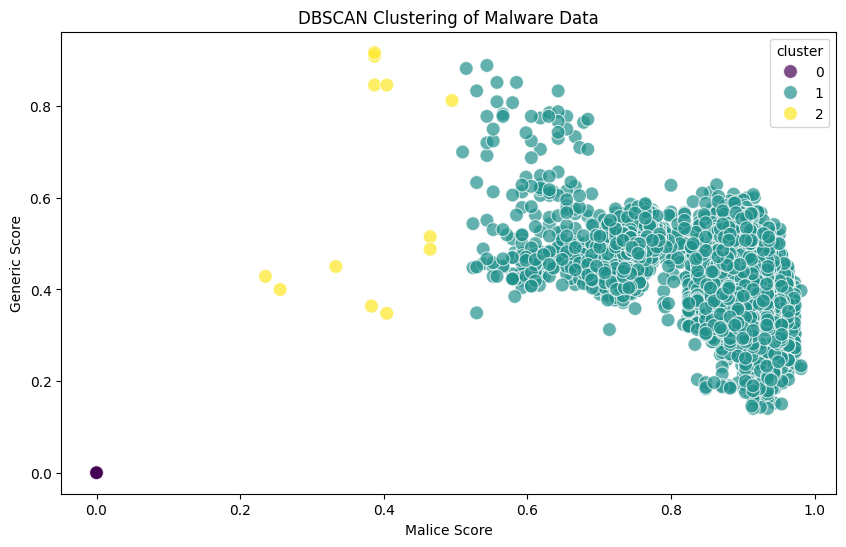

In [19]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# Apply DBSCAN clustering on the features
dbscan = DBSCAN(eps=0.5, min_samples=5)
combined_data['cluster'] = dbscan.fit_predict(X)

# Visualize the clustering results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined_data, x='malice', y='generic', hue='cluster', palette='viridis', s=100, alpha=0.7)
plt.title('DBSCAN Clustering of Malware Data')
plt.xlabel('Malice Score')
plt.ylabel('Generic Score')
plt.show()


In [20]:
# Example: Reconstruct event sequences by correlating disk artifacts and memory traces (simple placeholder)
event_log = pd.DataFrame({
    'timestamp': ['2024-01-01 12:00', '2024-01-01 12:30', '2024-01-01 13:00'],
    'event_type': ['File Created', 'Process Started', 'Network Connection'],
    'malice_score': [0.8, 0.9, 0.7]
})

# Sort events by timestamp to reconstruct the timeline
event_log['timestamp'] = pd.to_datetime(event_log['timestamp'])
event_log_sorted = event_log.sort_values(by='timestamp')

# Print the event log
print("Reconstructed Event Log:")
print(event_log_sorted)


Reconstructed Event Log:
            timestamp          event_type  malice_score
0 2024-01-01 12:00:00        File Created           0.8
1 2024-01-01 12:30:00     Process Started           0.9
2 2024-01-01 13:00:00  Network Connection           0.7


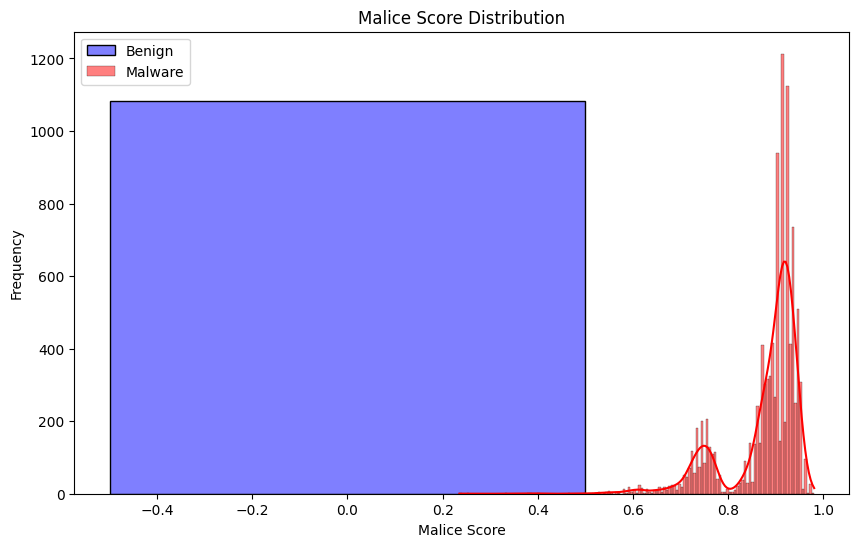

In [21]:
# Example: Histogram of malice scores for benign and malicious files
plt.figure(figsize=(10, 6))
sns.histplot(benign_labels['malice'], kde=True, color='blue', label='Benign')
sns.histplot(malware_labels['malice'], kde=True, color='red', label='Malware')
plt.legend()
plt.title('Malice Score Distribution')
plt.xlabel('Malice Score')
plt.ylabel('Frequency')
plt.show()


In [8]:
pip install volatility3


Note: you may need to restart the kernel to use updated packages.
